# Hugging Face Diffusion Course — Unit 1: Introduction to Diffusers

Source: https://huggingface.co/learn/diffusion-course/unit1/2

This notebook follows the official Diffusers introduction while adapting setup and artifact paths to this local `uv` project.

# Introduction to 🤗 Diffusers

We will use the official notebook as a guide, but run the work locally in this project.
The goal is to understand the main Diffusers pieces before training a small butterfly image generator.

## What this notebook will build toward

In the original notebook, we eventually:

- try a ready-made diffusion pipeline
- load image data from the Hugging Face Hub
- add noise with a scheduler
- train a small UNet model
- assemble the pieces into a mini image-generation pipeline

For now, we will go step by step and inspect each part before moving on.

## Step 1: Setup check

The Colab notebook installs packages with `%pip install`.
In this local repo, we use `uv` and keep dependencies in `pyproject.toml`.

Before importing anything, confirm that the environment can see the packages we need.

In [ ]:
import time
from pathlib import Path

import accelerate
import diffusers
import torch
import transformers

setup_start = time.perf_counter()

# Keep generated files under the repository root, even when this notebook runs from notebooks/.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_dir = project_root / "outputs" / "hf-course"
output_dir.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
setup_elapsed = time.perf_counter() - setup_start

print(f"setup configuration: {setup_elapsed:.2f}s")
print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("torch:", torch.__version__)
print("device:", device)
print("output dir:", output_dir.resolve())

## Helper: display generated images as a row

The course often displays several images together. This helper keeps that visual inspection step small and reusable.

In [8]:
from PIL import Image


def make_grid(images: list[Image.Image], size: int = 64) -> Image.Image:
    """Place PIL images next to each other for quick visual inspection.

    Args:
        images: Generated images to arrange in one row.
        size: Width and height for each resized image tile.

    Returns:
        A single PIL image containing all input images in a row.
    """
    output_image = Image.new("RGB", (size * len(images), size))

    for index, image in enumerate(images):
        output_image.paste(image.resize((size, size)), (index * size, 0))

    return output_image

## Step 2: Download a training dataset

The official notebook uses a small Hugging Face Hub dataset of butterfly images. Loading one example first confirms that the data is available before we resize it for training.

Repo card metadata block was not found. Setting CardData to empty.


rows: 1000
columns: ['image_url', 'image_alt', 'id', 'name', 'scientific_name', 'gender', 'taxonomy', 'region', 'locality', 'date', 'usnm_no', 'guid', 'edan_url', 'source', 'stage', 'image', 'image_hash', 'sim_score']


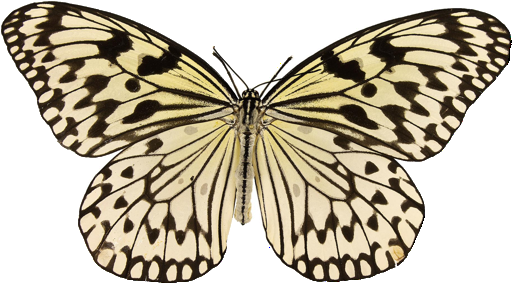

In [9]:
from datasets import load_dataset

dataset = load_dataset("huggan/smithsonian_butterflies_subset", split="train")

print("rows:", len(dataset))
print("columns:", dataset.column_names)

dataset[0]["image"]

## Step 2b: Preprocess images for training

The dataset gives us PIL images, but the UNet needs fixed-size PyTorch tensors. This cell resizes each butterfly to `32×32`, converts pixels to numbers, normalizes those numbers around zero, and groups examples into batches.

What to inspect after running it: the batch should have shape `[batch, 3, 32, 32]`, and the displayed grid should still look like recognizable butterfly images.


torch.Size([64, 3, 32, 32])


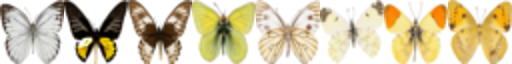

In [10]:
from torchvision import transforms

image_size = 32
batch_size = 64

preprocess = transforms.Compose(
    [
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)


def transform(examples: dict[str, list[Image.Image]]) -> dict[str, list[torch.Tensor]]:
    """Preprocess butterfly images for diffusion training.

    Args:
        examples: A batch of dataset rows containing PIL images.

    Returns:
        A dictionary with transformed image tensors.
    """
    images = [preprocess(image.convert("RGB")) for image in examples["image"]]
    return {"images": images}


dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
)

batch = next(iter(train_dataloader))
print(batch["images"].shape)

show_images = make_grid([transforms.ToPILImage()((image * 0.5 + 0.5).clamp(0, 1)) for image in batch["images"][:8]])

show_images

## Step 3: Add noise with a scheduler

A scheduler controls how much random noise gets added to an image at each timestep. Early timesteps keep more of the clean image, while later timesteps hide more of it under noise.

This is the forward diffusion process: create a controlled noisy input so the model can later learn to predict the noise that was added.


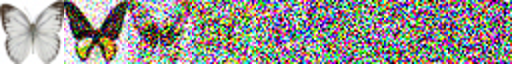

In [11]:
from diffusers import DDPMScheduler

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

clean_images = batch["images"][:8]
noise = torch.randn_like(clean_images)
timesteps = torch.linspace(0, 999, clean_images.shape[0]).long()

noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

noisy_grid = make_grid([transforms.ToPILImage()((image * 0.5 + 0.5).clamp(0, 1)) for image in noisy_images])

noisy_grid

## Step 4: Define the UNet model

The UNet receives a noisy image and a timestep, then predicts the noise that was added.

In [12]:
from diffusers import UNet2DModel

model = UNet2DModel(
    sample_size=image_size,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

model = model.to(device)

## Step 4b: Check the UNet input and output shapes

Before training, run one forward pass. The noisy image, the real noise, and the predicted noise should all have the same shape.

Good enough here means shape agreement, not a good prediction yet—the model has not learned anything until optimizer steps update its weights.


In [13]:
clean_images = batch["images"][:8].to(device)
noise = torch.randn_like(clean_images)
timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (clean_images.shape[0],),
    device=device,
).long()

noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
noise_prediction = model(noisy_images, timesteps).sample

print("noisy images:", noisy_images.shape)
print("actual noise:", noise.shape)
print("predicted noise:", noise_prediction.shape)

noisy images: torch.Size([8, 3, 32, 32])
actual noise: torch.Size([8, 3, 32, 32])
predicted noise: torch.Size([8, 3, 32, 32])


## Step 5: Measure one-batch loss

Loss is one number that measures how different the predicted noise is from the actual noise. Here we use mean squared error, which averages `(predicted_noise - actual_noise)²` over the whole tensor.

At this point the value only confirms that the training objective is wired correctly; it is not expected to be low yet.


In [14]:
import torch.nn.functional as F

loss = F.mse_loss(noise_prediction, noise)

print("loss:", loss.item())

loss: 1.1547478437423706


## Step 6: Run one optimizer update

An optimizer update is the smallest complete training move: predict noise, compute loss, backpropagate gradients, and change the model weights once.

The printed loss is measured before the weight update, so do not expect this single number to prove improvement by itself.


In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

model.train()

clean_images = batch["images"].to(device)
noise = torch.randn_like(clean_images)
timesteps = torch.randint(
    0,
    noise_scheduler.config.num_train_timesteps,
    (clean_images.shape[0],),
    device=device,
).long()

noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
noise_prediction = model(noisy_images, timesteps).sample

loss = F.mse_loss(noise_prediction, noise)

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("one-step training loss:", loss.item())

one-step training loss: 1.146018385887146


## Step 7: Train for a few short epochs

The training loop repeats the same denoising practice over many batches. Each batch chooses fresh noise and fresh timesteps, so individual losses can bounce around.

Watch the rough trend across many printed losses rather than judging one step in isolation.


In [19]:
from tqdm.auto import tqdm

losses = []
num_epochs = 2

model.train()

for epoch in range(num_epochs):
    for step, batch in enumerate(tqdm(train_dataloader)):
        clean_images = batch["images"].to(device)
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(
            0,
            noise_scheduler.config.num_train_timesteps,
            (clean_images.shape[0],),
            device=device,
        ).long()

        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)
        noise_prediction = model(noisy_images, timesteps).sample

        loss = F.mse_loss(noise_prediction, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if step % 5 == 0:
            print(f"epoch {epoch} step {step} loss {loss.item():.4f}")

  0%|          | 0/16 [00:00<?, ?it/s]

epoch 0 step 0 loss 0.0548
epoch 0 step 5 loss 0.0687
epoch 0 step 10 loss 0.0538
epoch 0 step 15 loss 0.0715


  0%|          | 0/16 [00:00<?, ?it/s]

epoch 1 step 0 loss 0.0449
epoch 1 step 5 loss 0.0727
epoch 1 step 10 loss 0.0524
epoch 1 step 15 loss 0.0452


## Training note and inspection checkpoint

Record the rough loss trend you observed here before moving to image sampling. A lower training loss means the UNet is getting better at predicting added noise, but it does not automatically mean generated images will look good.

Human-in-the-loop checkpoint: after sampling images later, save a representative artifact under `outputs/hf-course/`, tweak one safe parameter, and write a short note about what changed.


## Step 8: Generate sample images

Now we use the trained UNet and scheduler together as a DDPM pipeline.
The pipeline starts from random noise and repeatedly denoises it into images.

  0%|          | 0/100 [00:00<?, ?it/s]

saved: ..\outputs\hf-course\unit1_generated_samples_seed0_steps100.png


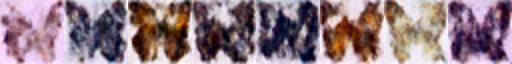

In [22]:
from diffusers import DDPMPipeline

model.eval()

image_pipe = DDPMPipeline(unet=model, scheduler=noise_scheduler).to(device)

generator = torch.Generator(device=device).manual_seed(0)

sample_images = image_pipe(
    batch_size=8,
    generator=generator,
    num_inference_steps=100,
).images

sample_grid = make_grid(sample_images, size=64)
sample_path = output_dir / "unit1_generated_samples_seed0_steps100.png"
sample_grid.save(sample_path)

print("saved:", sample_path)
sample_grid

## Visual inspection note

Generated sample path: `outputs/hf-course/unit1_generated_samples_seed0_steps100.png`

Observation: The images display correctly. They are recognizable and noisy butterfly-like images.